In [1]:
# BiocManager::install("SingleR")
# BiocManager::install("celldex")
# BiocManager::install("SingleCellExperiment")

In [2]:
library(Seurat)
library(patchwork)
library(tidyverse) 
library(SingleR)
library(celldex)
library(SingleCellExperiment)
library(dplyr)

set.seed(1234)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


In [3]:
# Define directories
dir_fig <- "../../results/sc_rna/01_merge/figures"
dir_int <- "../../results/sc_rna/01_merge/intermediate"

# Make sure directories exist
dir.create(dir_fig, recursive = TRUE, showWarnings = FALSE)
dir.create(dir_int, recursive = TRUE, showWarnings = FALSE)

# 1. Preprocessing

## Day3

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


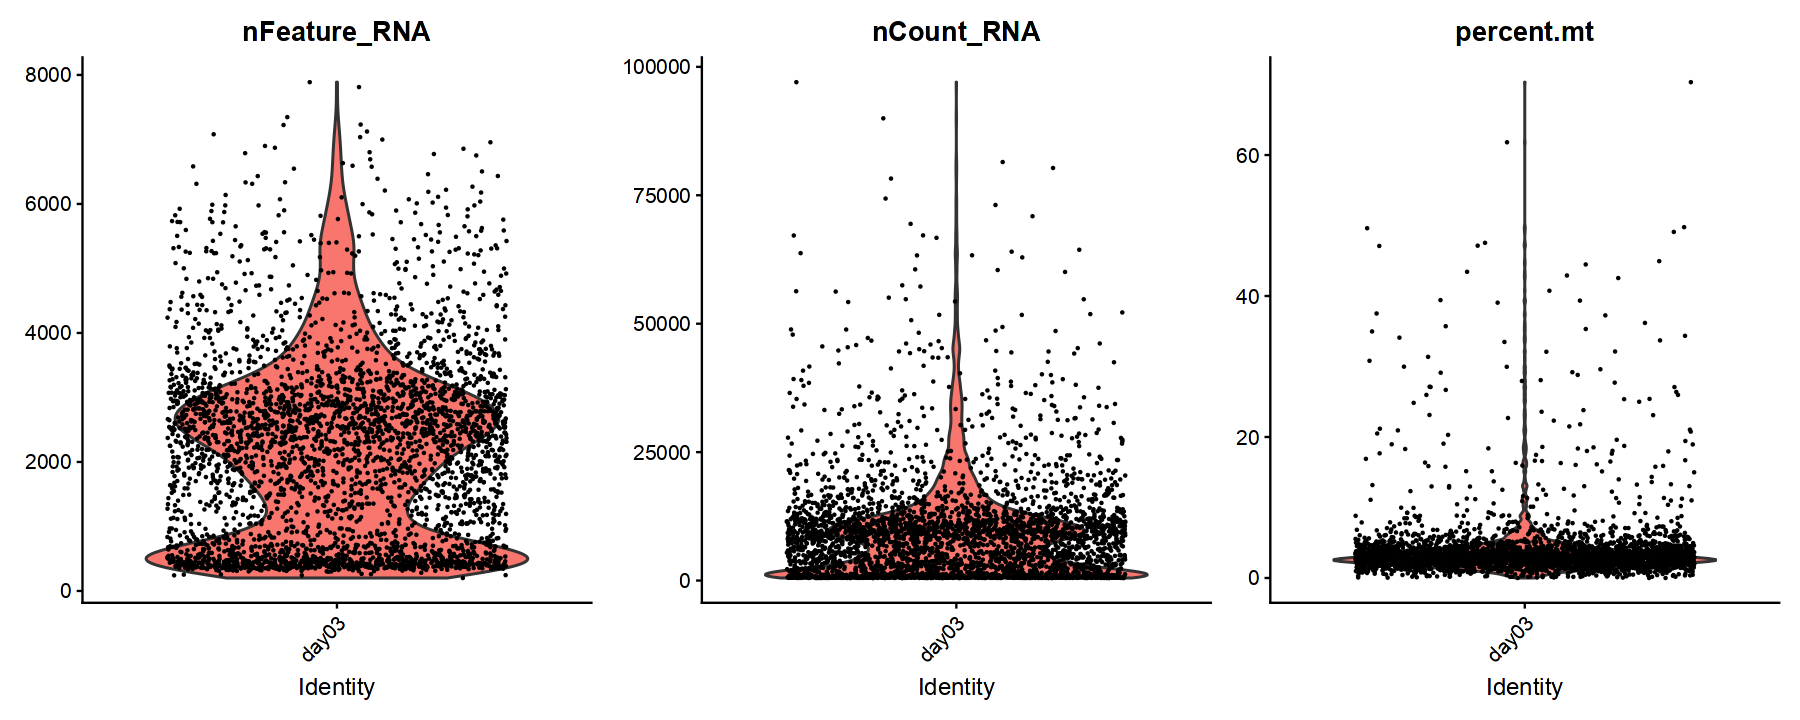

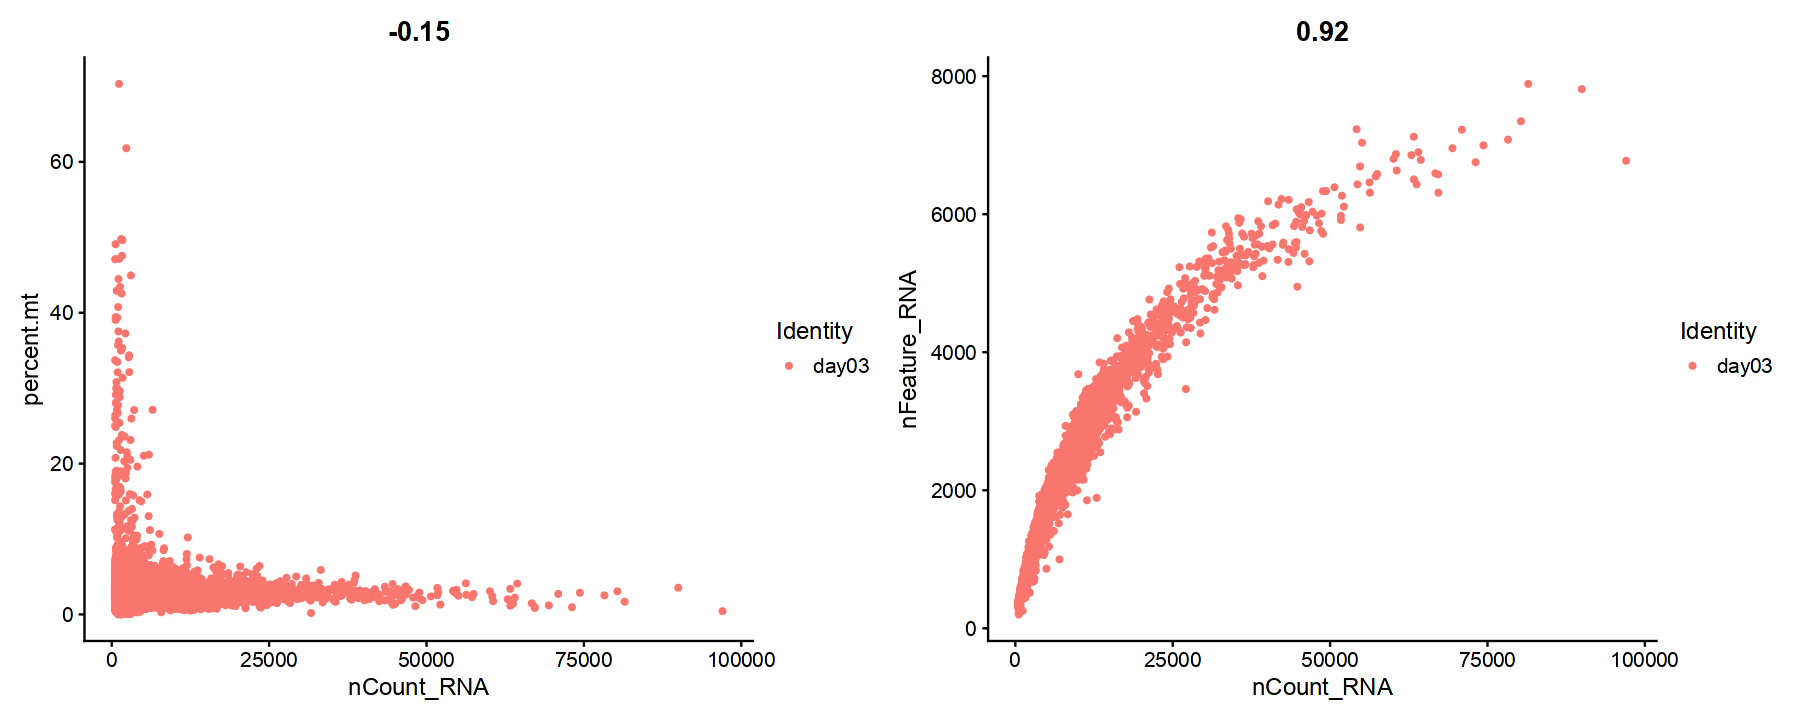

In [4]:
# Read the 10X count matrix
data_dir3 <- "../../data/scRNA/A1_B16_day_3/filtered_feature_bc_matrix"
expression_matrix3 <- Read10X(data.dir = data_dir3)

# Create a Seurat object
day3 <- CreateSeuratObject(
    counts = expression_matrix3,
    project = "day03",
    min.cells = 3,
    min.features = 200
)

# Calculate the percentage of mitochondrial transcripts
day3[["percent.mt"]] <- PercentageFeatureSet(
    day3,
    pattern = "^mt-"
)

# Generate QC plots before filtering
options(repr.plot.width = 15, repr.plot.height = 6)
VlnPlot(
    day3,
    features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
    ncol = 3,
    pt.size = 0.01
)

plot1 <- FeatureScatter(day3, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(day3, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


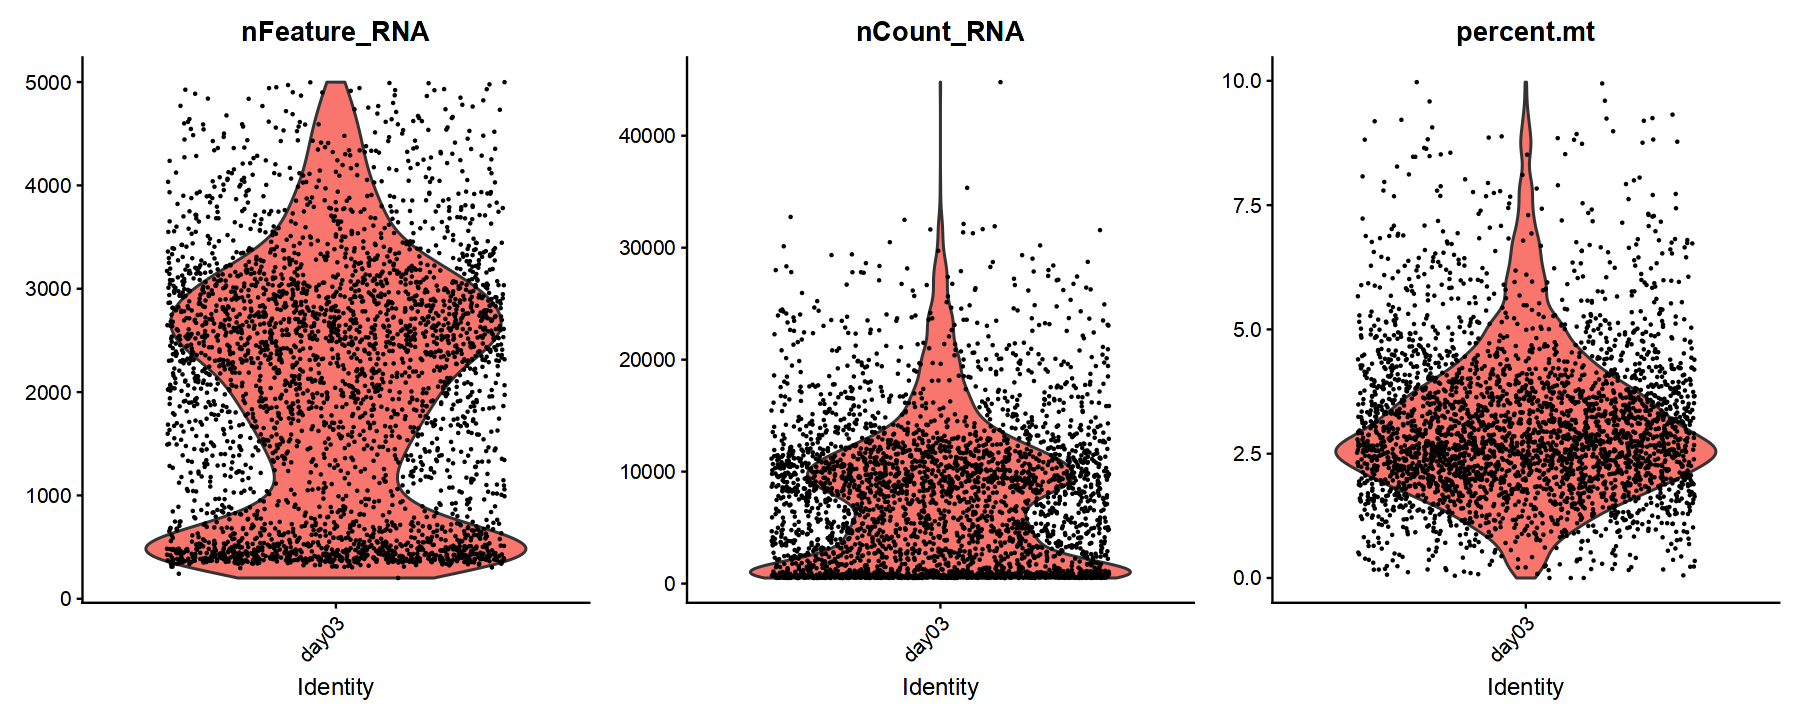

In [5]:
# Filter low-quality cells
day3 <- subset(
    day3,
    subset = nFeature_RNA > 200 & nFeature_RNA < 5000 & percent.mt < 10
)

# Generate QC plots after filtering
VlnPlot(
    day3,
    features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
    ncol = 3,
    pt.size = 0.01
)

## Day7

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


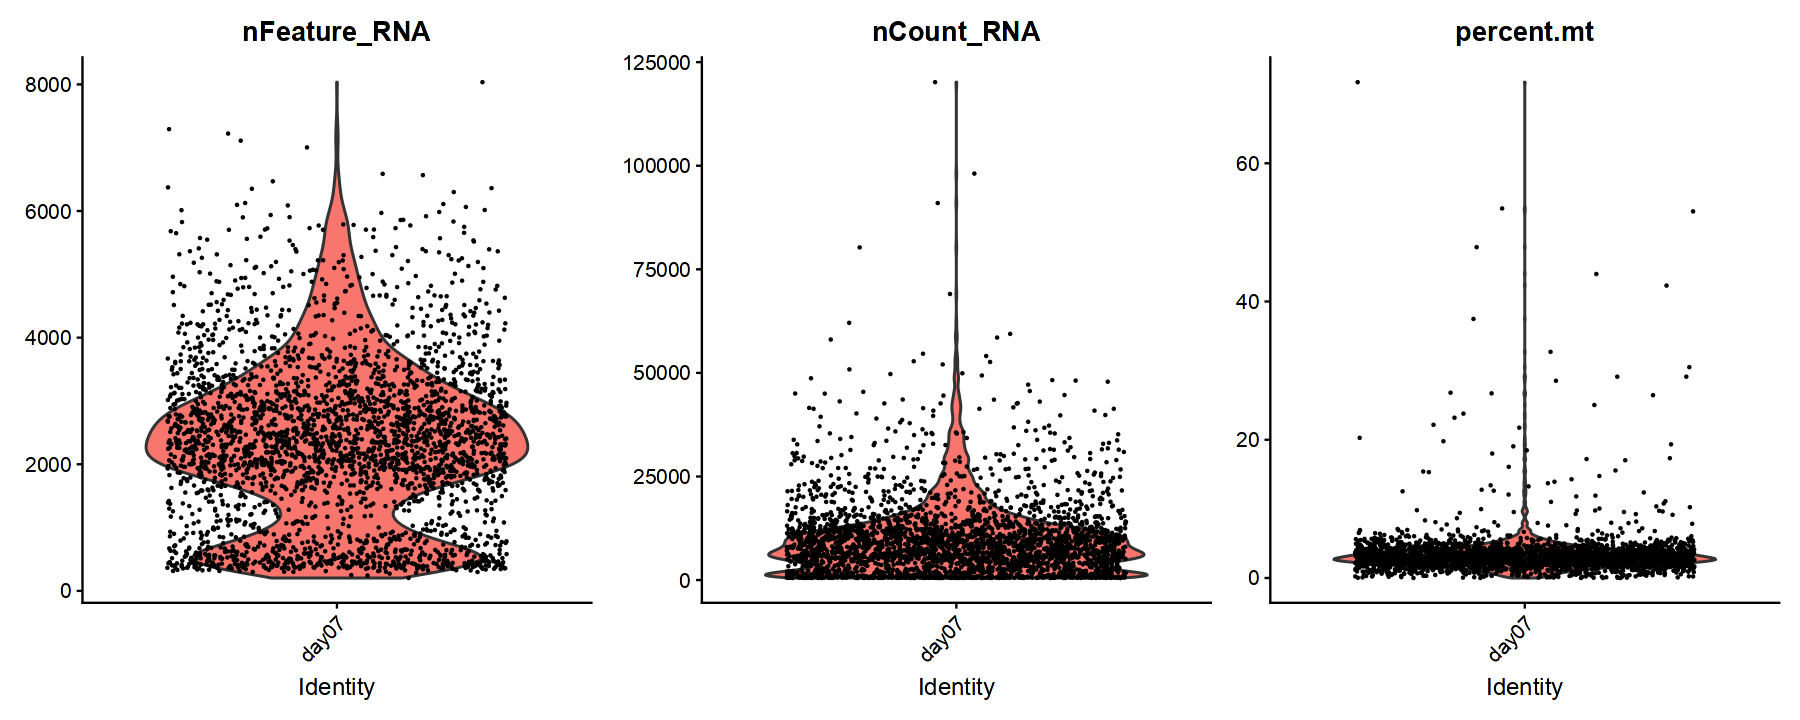

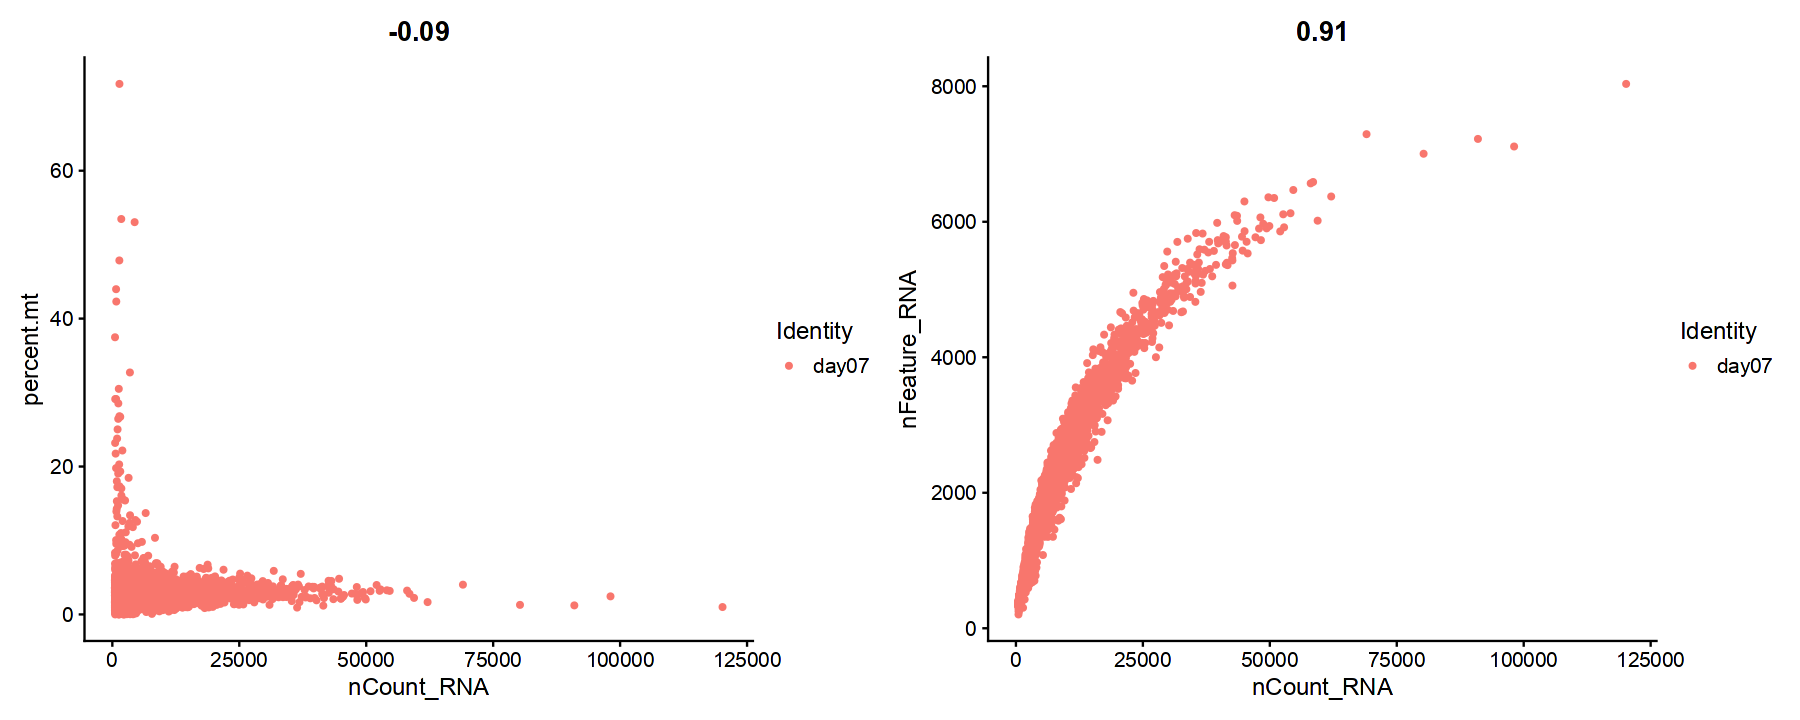

In [6]:
# Read the 10X count matrix
data_dir7 <- "../../data/scRNA/A2_B16_day_7/filtered_feature_bc_matrix"
expression_matrix7 <- Read10X(data.dir = data_dir7)

# Create a Seurat object
day7 <- CreateSeuratObject(
    counts = expression_matrix7,
    project = "day07",
    min.cells = 3,
    min.features = 200
)

# Calculate the percentage of mitochondrial transcripts
day7[["percent.mt"]] <- PercentageFeatureSet(
    day7,
    pattern = "^mt-"
)

# Generate QC plots before filtering
options(repr.plot.width = 15, repr.plot.height = 6)
VlnPlot(
    day7,
    features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
    ncol = 3,
    pt.size = 0.01
)

plot1 <- FeatureScatter(day7, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(day7, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


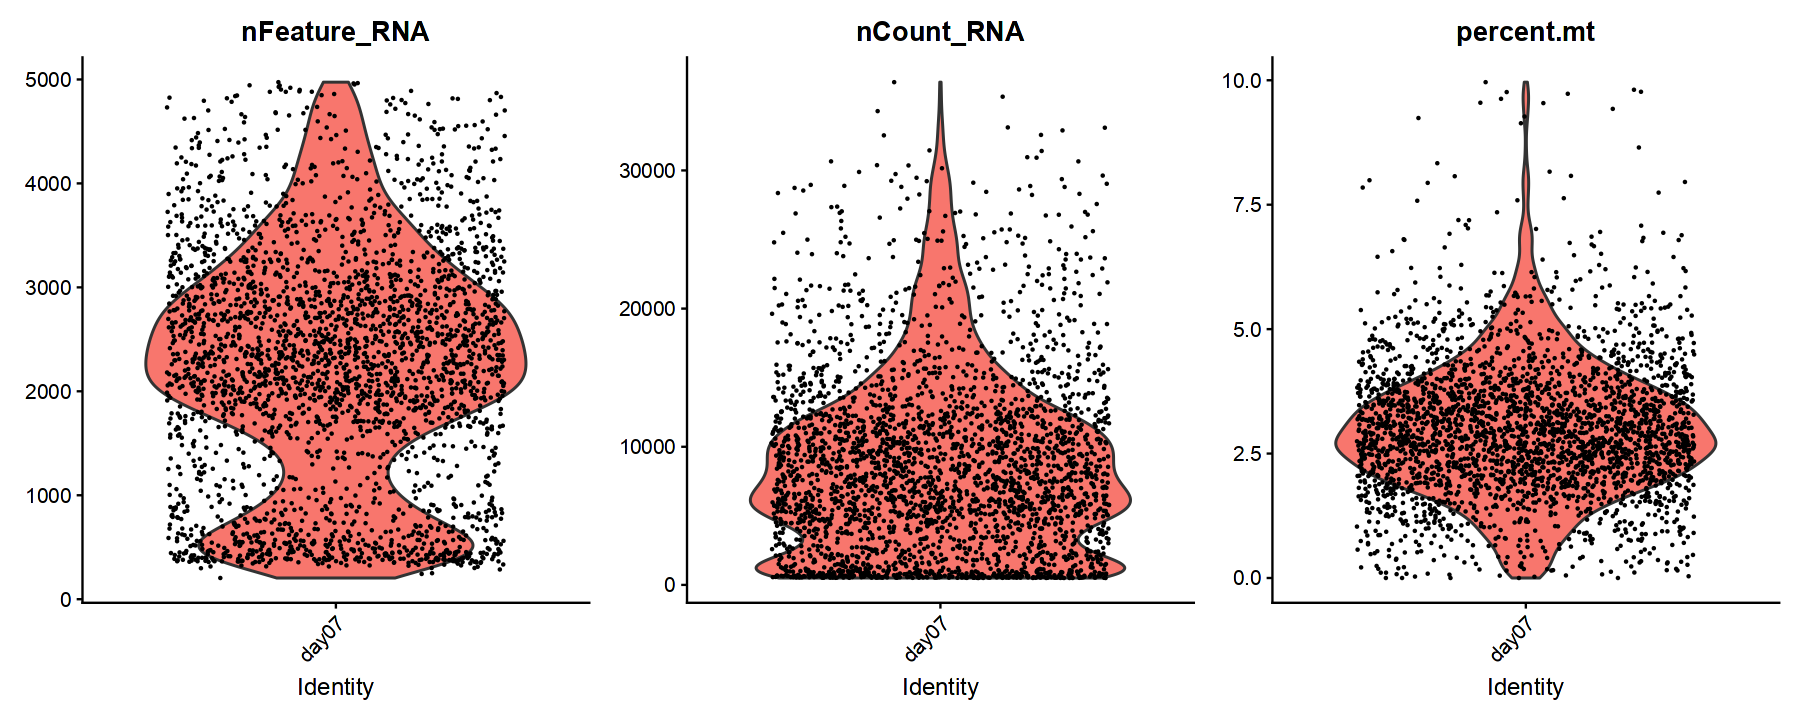

In [7]:
# Filter low-quality cells
day7 <- subset(
    day7,
    subset = nFeature_RNA > 200 & nFeature_RNA < 5000 & percent.mt < 10
)

# Generate QC plots after filtering
VlnPlot(
    day7,
    features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
    ncol = 3,
    pt.size = 0.01
)

## Day14

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


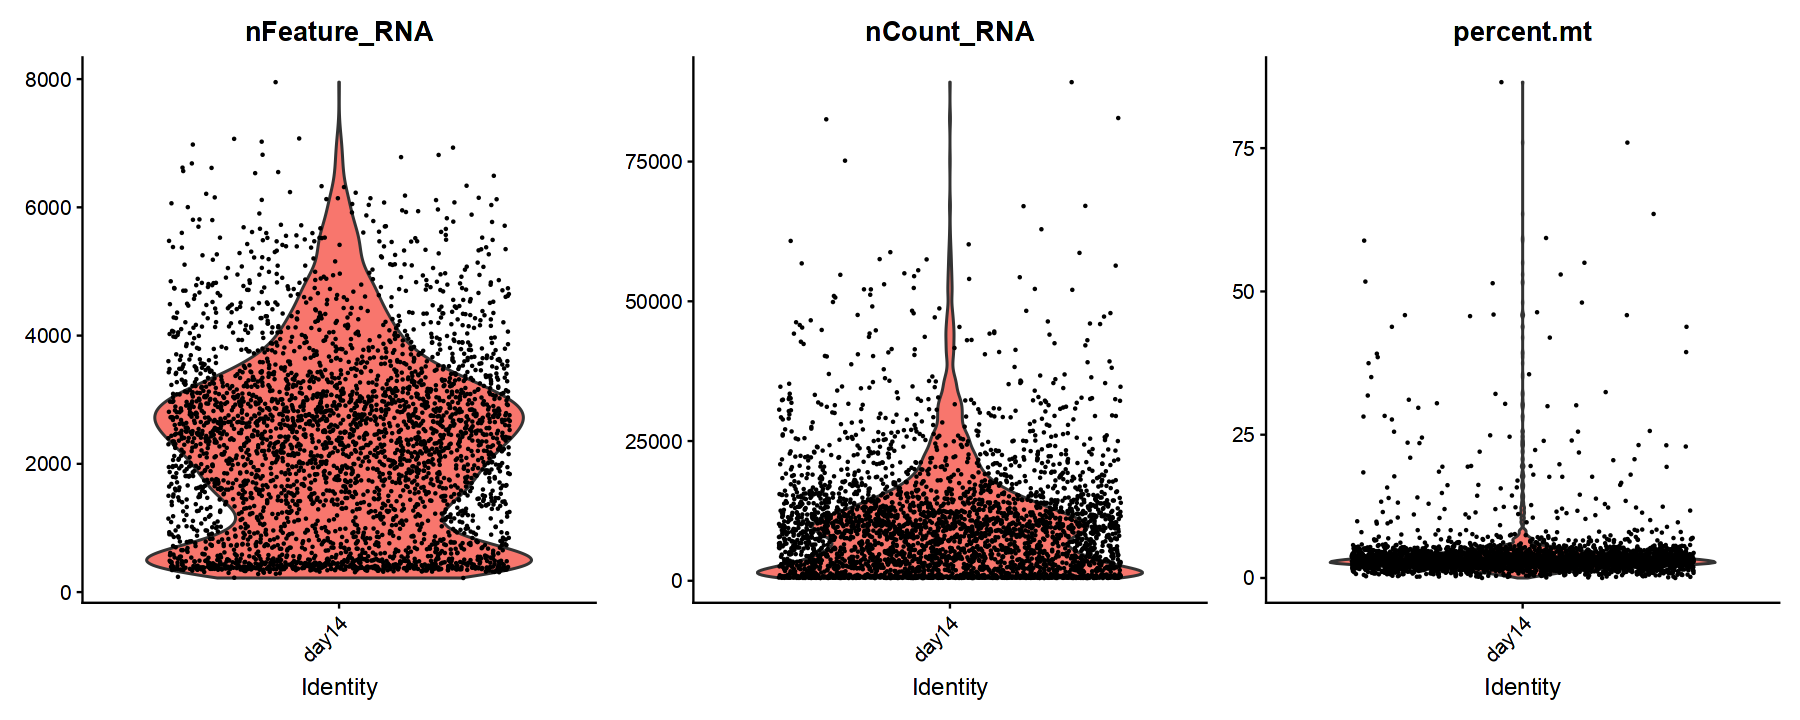

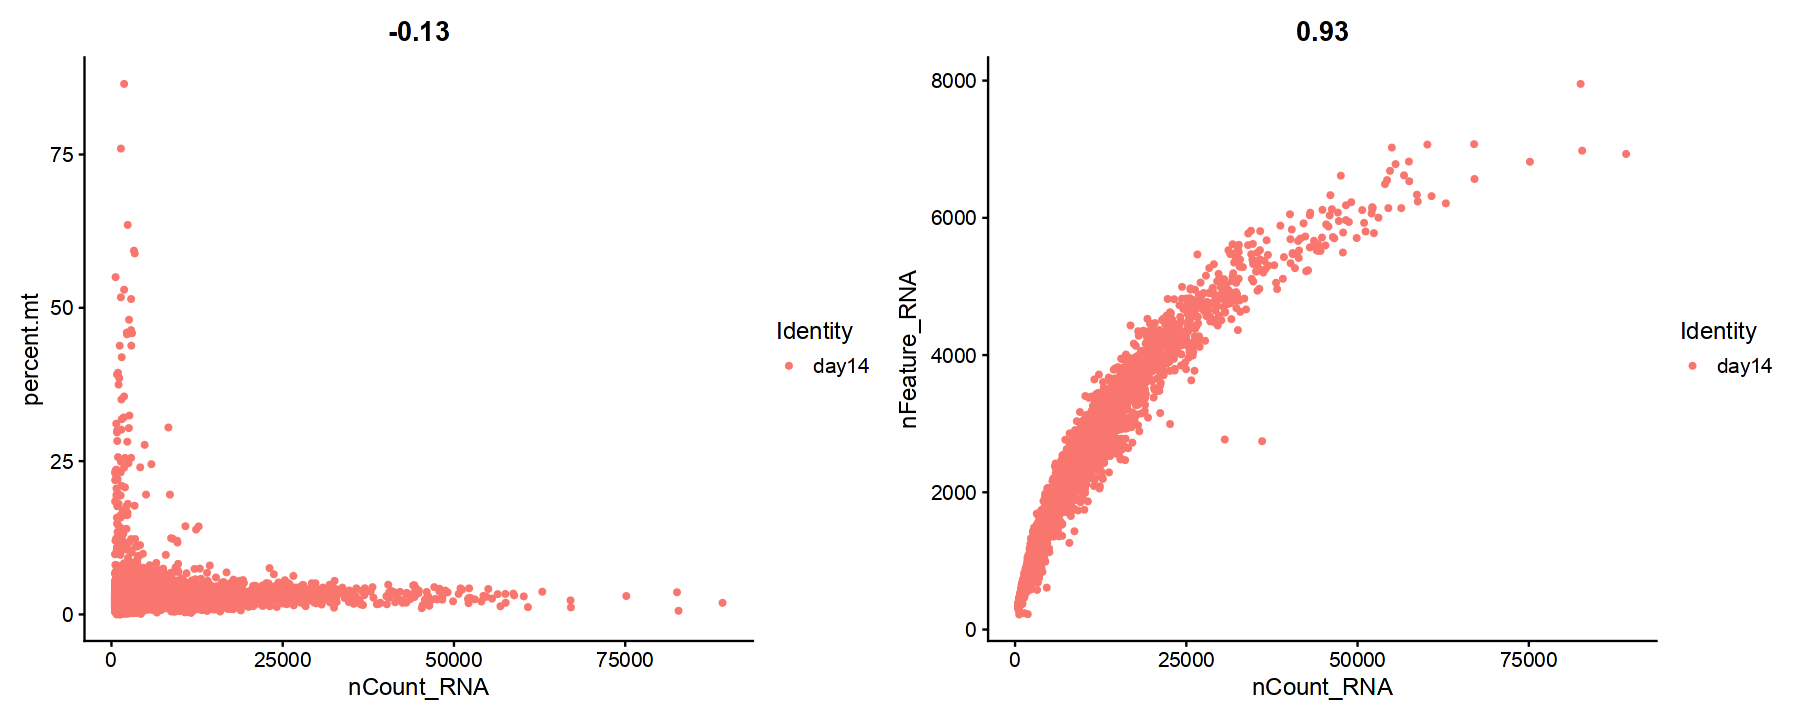

In [8]:
# Read the 10X count matrix
data_dir14 <- "../../data/scRNA/A3_B16_day_14/filtered_feature_bc_matrix"
expression_matrix14 <- Read10X(data.dir = data_dir14)

# Create a Seurat object
day14 <- CreateSeuratObject(
    counts = expression_matrix14,
    project = "day14",
    min.cells = 3,
    min.features = 200
)

# Calculate the percentage of mitochondrial transcripts
day14[["percent.mt"]] <- PercentageFeatureSet(
    day14,
    pattern = "^mt-"
)

# Generate QC plots before filtering
options(repr.plot.width = 15, repr.plot.height = 6)
VlnPlot(
    day14,
    features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
    ncol = 3,
    pt.size = 0.01
)

plot1 <- FeatureScatter(day14, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(day14, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


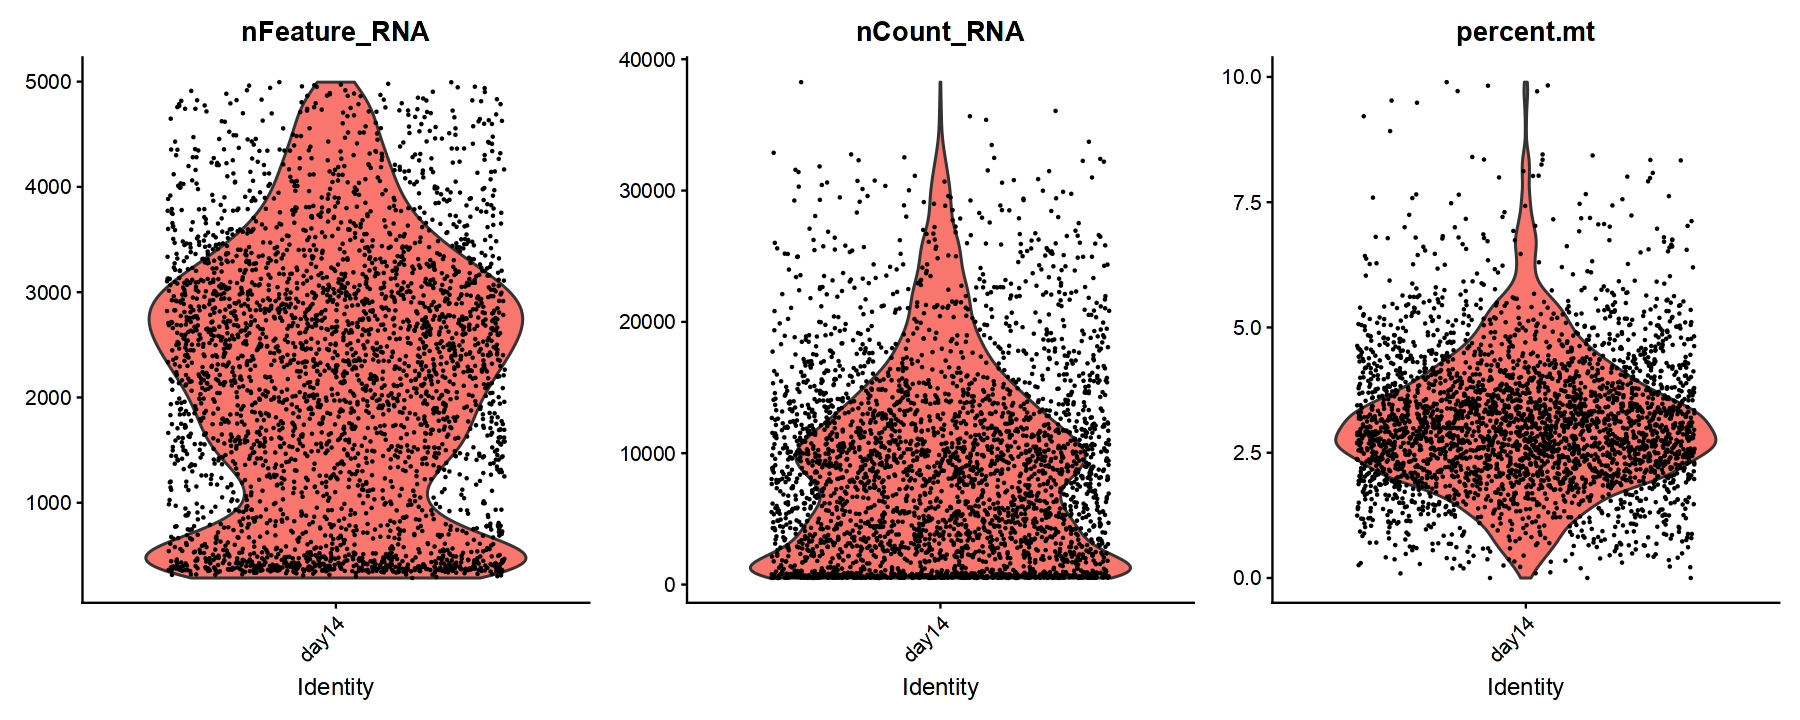

In [9]:
# Filter low-quality cells
day14 <- subset(
    day14,
    subset = nFeature_RNA > 200 & nFeature_RNA < 5000 & percent.mt < 10
)

# Generate QC plots after filtering
VlnPlot(
    day14,
    features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
    ncol = 3,
    pt.size = 0.01
)

## Save

In [10]:
saveRDS(day3, file = file.path(dir_int, "day3_qc_filtered.rds"))
saveRDS(day7, file = file.path(dir_int, "day7_qc_filtered.rds"))
saveRDS(day14, file = file.path(dir_int, "day14_qc_filtered.rds"))

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’



In [11]:
day3

An object of class Seurat 
15176 features across 3354 samples within 1 assay 
Active assay: RNA (15176 features, 0 variable features)
 1 layer present: counts

In [12]:
day7

An object of class Seurat 
15087 features across 2881 samples within 1 assay 
Active assay: RNA (15087 features, 0 variable features)
 1 layer present: counts

In [13]:
day14

An object of class Seurat 
15371 features across 3292 samples within 1 assay 
Active assay: RNA (15371 features, 0 variable features)
 1 layer present: counts

# 2. Merge

In [14]:
# Add sample metadata
day3$day <- "Day3"
day7$day <- "Day7"
day14$day <- "Day14"

# Merge the three datasets
merged <- merge(
    x = day3,
    y = list(day7, day14),
    add.cell.ids = c("Day3", "Day7", "Day14")
)

# Set the sample order
merged$day <- factor(merged$day, levels = c("Day3", "Day7", "Day14"))

# Join layers after merging for downstream analysis without integration
merged <- JoinLayers(merged)

In [15]:
# Normalize the merged dataset
merged <- NormalizeData(merged, verbose = FALSE)

# Identify highly variable features
merged <- FindVariableFeatures(
    merged,
    selection.method = "vst",
    nfeatures = 2000,
    verbose = FALSE
)

# Scale the data
merged <- ScaleData(
    merged,
    features = rownames(merged),
    verbose = FALSE
)

# Perform PCA using variable features
merged <- RunPCA(
    merged,
    features = VariableFeatures(merged),
    verbose = FALSE
)

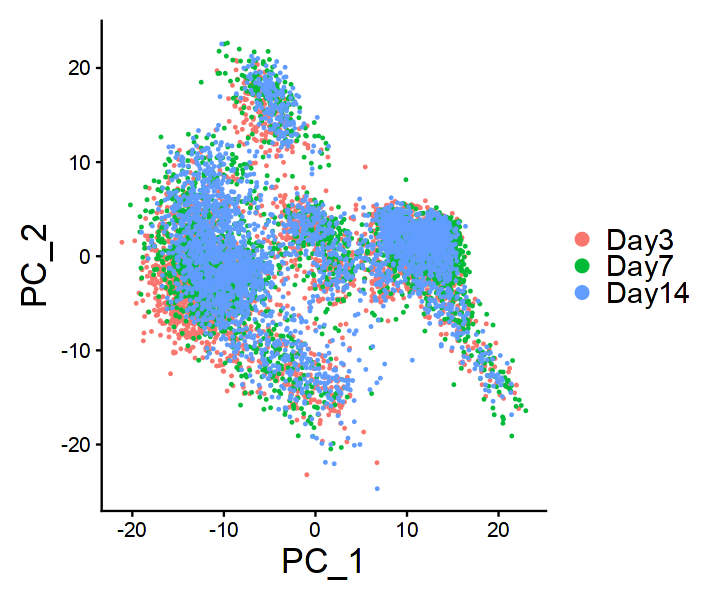

In [16]:
options(repr.plot.width = 6, repr.plot.height = 5)
DimPlot(merged, reduction = "pca", group.by = "day") + theme(text = element_text(size = 20)) + ggtitle(NULL)

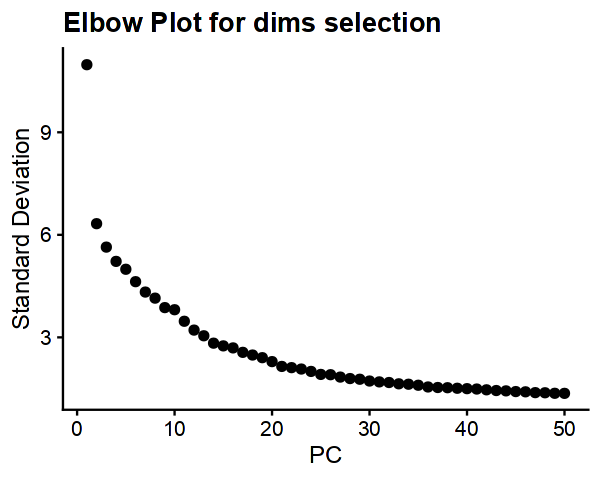

In [17]:
options(repr.plot.width = 5, repr.plot.height = 4)
ElbowPlot(merged, ndims = 50) + ggtitle("Elbow Plot for dims selection")

In [18]:
saveRDS(merged, file = file.path(dir_int, "merged_pca.rds"))

In [19]:
sessionInfo()

R version 4.5.1 (2025-06-13)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/atlas/libblas.so.3.10.3 
LAPACK: /usr/lib/x86_64-linux-gnu/atlas/liblapack.so.3.10.3;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] SingleCellExperiment_1.30.1 celldex_1.18.0             
 [3] SingleR_2.10.0              SummarizedExperiment_1.38.1
 [5] Biobase_2.68.0              GenomicRanges_1.60.0       
 [7] GenomeInfoDb_1.44.2         IRanges_2.42.0             
